In [1]:
# =========================
# FINAL CLEAN EM (WARMUP + FREEZE VARIANCES)
# =========================

import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

EPS = 1e-6
MAX_VAL = 1e6

# =========================
# DATA PREP
# =========================

def prepare_data(df):

    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    level_map = {"I":0, "II":1, "III":2, "IV":3}

    L_raw = df["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    # build wage (before filtering so mask is consistent)
    y_raw = np.log(df["wage_ratio"].values)

    # mask: keep only valid rows
    mask = (
    L.notna() &                  # remove unmapped levels
    np.isfinite(y_raw)           # removes inf and -inf
    )

    # apply mask to df
    df = df.loc[mask].copy()

    # now rebuild
    L = L.loc[mask].astype(np.int64).values
    y = np.maximum(y_raw[mask], 0)
    censored = (y == 0)


    
    S = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes

   

    return {
        "y": y,
        "censored": censored,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(np.unique(E)),
        "N_S": len(np.unique(S)),
        "N_ST": len(np.unique(ST))
    }

# =========================
# E STEP
# =========================

def truncated_normal_moments(mu, sigma):

    sigma = np.maximum(sigma, EPS)
    alpha = np.clip(-mu / sigma, -10, 10)

    phi = stats.norm.pdf(alpha)
    Phi = np.clip(stats.norm.cdf(alpha), 1e-10, 1.0)

    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)

    E1 = mu - sigma * ratio
    E2 = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio

    return E1, E2

def e_step(y, censored, mu, sigma):

    y_star = y.copy()
    y_star2 = y**2

    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma)
        y_star[censored] = E1
        y_star2[censored] = E2

    return y_star, y_star2

# =========================
# SAFE VARIANCE UPDATES
# =========================

def update_sigma(alpha):
    return max((np.sum(alpha**2) + 0.1) / (len(alpha) + 2), 1e-4)

def update_sigma2(resid2):
    return max((np.sum(resid2) + 0.1) / (len(resid2) + 2), 1e-4)

def damp(old, new, w=0.1):
    return (1-w)*old + w*new

# =========================
# M STEP (MEANS ONLY)
# =========================

def m_step(y_star, y_star2, L, E, S, ST,
           gamma, alpha, delta, eta,
           sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2):

    n = len(y_star)

    lam_L = min(sigma2 / sigma_L2, MAX_VAL)
    lam_E = min(sigma2 / sigma_E2, MAX_VAL)
    lam_S = min(sigma2 / sigma_S2, MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)

    K, N_E, N_S, N_ST = len(gamma), len(alpha), len(delta), len(eta)

    n_L = np.bincount(L, minlength=K)
    n_E = np.bincount(E, minlength=N_E)
    n_S = np.bincount(S, minlength=N_S)
    n_ST = np.bincount(ST, minlength=N_ST)

    Sy_L = np.bincount(L, weights=y_star, minlength=K)
    Sy_E = np.bincount(E, weights=y_star, minlength=N_E)
    Sy_S = np.bincount(S, weights=y_star, minlength=N_S)
    Sy_ST = np.bincount(ST, weights=y_star, minlength=N_ST)

    Sy_total = y_star.sum()

    for _ in range(30):

        beta0 = (Sy_total - (gamma[L] + alpha[E] + delta[S] + eta[ST]).sum()) / n

        gamma = (Sy_L - np.bincount(L, weights=alpha[E]+delta[S]+eta[ST], minlength=K) - n_L*beta0) / (n_L + lam_L)
        alpha = (Sy_E - np.bincount(E, weights=gamma[L]+delta[S]+eta[ST], minlength=N_E) - n_E*beta0) / (n_E + lam_E)
        delta = (Sy_S - np.bincount(S, weights=gamma[L]+alpha[E]+eta[ST], minlength=N_S) - n_S*beta0) / (n_S + lam_S)
        eta   = (Sy_ST - np.bincount(ST, weights=gamma[L]+alpha[E]+delta[S], minlength=N_ST) - n_ST*beta0) / (n_ST + lam_ST)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    resid2 = np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2 = update_sigma2(resid2)

    return beta0, gamma, alpha, delta, eta, sigma2, mu

# =========================
# LOG LIKELIHOOD
# =========================

def observed_ll(y, censored, mu, sigma):

    sigma = max(sigma, 1e-4)

    ll = 0
    if (~censored).any():
        ll += stats.norm.logpdf(y[~censored], mu[~censored], sigma).sum()

    if censored.any():
        ll += np.log(np.clip(stats.norm.cdf(0, mu[censored], sigma), 1e-10, 1)).sum()

    return ll

# =========================
# FIT MODEL
# =========================

def fit_model_l(data, max_iter=50):

    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']


    print(L.dtype, E.dtype, S.dtype, ST.dtype)
    print(type(L[0]), L[:5])
    
    gamma = np.zeros(data['K'])
    alpha = np.zeros(data['N_E'])
    delta = np.zeros(data['N_S'])
    eta   = np.zeros(data['N_ST'])

    beta0 = np.mean(y)

    sigma2 = 1.0
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1

    lls = []
    history = []

    for it in range(max_iter):

        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2))

        beta0, gamma, alpha, delta, eta, sigma2, mu = m_step(
            y_star, y_star2, L, E, S, ST,
            gamma, alpha, delta, eta,
            sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2
        )

        # Warmup → Freeze
        if it < 10:
            sigma_E2 = damp(sigma_E2, update_sigma(alpha))
            sigma_L2 = damp(sigma_L2, update_sigma(gamma))
            sigma_S2 = damp(sigma_S2, update_sigma(delta))
            sigma_ST2 = damp(sigma_ST2, update_sigma(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2))
        lls.append(ll)

        history.append({
            "sigma": np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2),
            "sigma_L": np.sqrt(sigma_L2),
            "sigma_S": np.sqrt(sigma_S2),
            "sigma_ST": np.sqrt(sigma_ST2)
        })

        print(f"iter {it}: ll={ll:.2f}")

        if it > 2 and abs(lls[-1] - lls[-2]) < 1:
            break

    return {
        "beta0": beta0,
        "gamma": gamma,
        "alpha": alpha,
        "delta": delta,
        "eta": eta,
        "sigma": np.sqrt(sigma2),
        "lls": lls,
        "history": history,
        "data": data
    }

# =========================
# DIAGNOSTICS
# =========================

def plot_results(result):

    data = result["data"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    sigma = result["sigma"]
    y = data["y"]

    fig = plt.figure(figsize=(16,10))
    gs = gridspec.GridSpec(2,4)

    plt.subplot(gs[0,0]); plt.plot(result["lls"]); plt.title("LL")
    plt.subplot(gs[0,1]); plt.hist(result["alpha"], bins=40); plt.title("Employer")
    plt.subplot(gs[0,2]); plt.bar(range(4), result["gamma"]); plt.title("Level")
    plt.subplot(gs[0,3]); plt.hist(result["delta"], bins=30); plt.title("SOC")

    plt.subplot(gs[1,0]); plt.hist(result["eta"], bins=30); plt.title("State")

    plt.subplot(gs[1,1])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0)
    plt.hist(y[y>0], bins=50, density=True, alpha=0.5)
    plt.hist(y_sim[y_sim>0], bins=50, density=True, alpha=0.5)
    plt.title("Posterior Predictive")

    plt.subplot(gs[1,2])
    stats.probplot((y[y>0]-mu[y>0])/sigma, plot=plt)

    plt.subplot(gs[1,3])
    plt.plot(np.diff(result["lls"]))
    plt.axhline(0)

    plt.tight_layout()
    plt.show()

# =========================
# RUN
# =========================


if __name__ == "__main__":

    df = pd.read_parquet("final_filtered.parquet")

    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df = df[df["EMPLOYER_NAME_CLEAN"].map(df["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100]

    data = prepare_data(df)

    result = fit_model_l(data)

int64 int16 int8 int8
<class 'numpy.int64'> [1 1 2 0 1]
iter 0: ll=323222.20
iter 1: ll=568158.62
iter 2: ll=627668.02
iter 3: ll=650493.20
iter 4: ll=665266.01
iter 5: ll=676576.65
iter 6: ll=685443.61
iter 7: ll=692373.47
iter 8: ll=697735.14
iter 9: ll=701787.09
iter 10: ll=704702.12
iter 11: ll=706628.75
iter 12: ll=707745.06
iter 13: ll=708261.43
iter 14: ll=708390.28
iter 15: ll=708309.02
iter 16: ll=708141.38
iter 17: ll=707959.76
iter 18: ll=707798.79
iter 19: ll=707670.09
iter 20: ll=707573.60
iter 21: ll=707504.45
iter 22: ll=707456.66
iter 23: ll=707424.71
iter 24: ll=707404.13
iter 25: ll=707391.48
iter 26: ll=707384.24
iter 27: ll=707380.63
iter 28: ll=707379.41
iter 29: ll=707379.70


In [2]:
# =============================================================================
# HURDLE MODEL: Bernoulli censoring + Gamma positive log wage ratio
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, GammaRegressor
from scipy import sparse

EPS = 1e-8


def prepare_data_hurdle(df):
    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]

    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}

    L_raw = df["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    y_raw = np.log(df["wage_ratio"].values)

    mask = (
        L.notna()
        & np.isfinite(y_raw)
    )

    df = df.loc[mask].copy()

    L = L.loc[mask].astype(np.int64).values
    y = np.maximum(y_raw[mask], 0.0)
    censored = y == 0
    positive = ~censored

    S_cat = pd.Categorical(df["SOC_F"])
    ST_cat = pd.Categorical(df["STATE_F"])
    E_cat = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])

    S = S_cat.codes.astype(np.int64)
    ST = ST_cat.codes.astype(np.int64)
    E = E_cat.codes.astype(np.int64)

    return {
        "df": df,
        "y": y,
        "censored": censored,
        "positive": positive,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(E_cat.categories),
        "N_S": len(S_cat.categories),
        "N_ST": len(ST_cat.categories),
        "E_categories": list(E_cat.categories),
        "S_categories": list(S_cat.categories),
        "ST_categories": list(ST_cat.categories),
        "N": len(df)
    }


# =============================================================================
# DESIGN MATRIX
# =============================================================================

def make_design_matrix(data, idx=None, encoder=None, fit_encoder=False):
    """
    Sparse one-hot design matrix for:
        wage level + employer + SOC + state

    We do not drop a reference category because the L2 penalty stabilizes the fit.
    This makes coefficient extraction easier.
    """
    if idx is None:
        idx = np.arange(data["N"])

    X_raw = np.column_stack([
        data["L"][idx],
        data["E"][idx],
        data["S"][idx],
        data["ST"][idx],
    ])

    categories = [
        np.arange(data["K"]),
        np.arange(data["N_E"]),
        np.arange(data["N_S"]),
        np.arange(data["N_ST"]),
    ]

    if encoder is None:
        try:
            encoder = OneHotEncoder(
                categories=categories,
                sparse_output=True,
                handle_unknown="ignore"
            )
        except TypeError:
            # for older sklearn versions
            encoder = OneHotEncoder(
                categories=categories,
                sparse=True,
                handle_unknown="ignore"
            )

    if fit_encoder:
        X = encoder.fit_transform(X_raw)
    else:
        X = encoder.transform(X_raw)

    return X, encoder


# =============================================================================
# FIT HURDLE MODEL
# =============================================================================

def fit_hurdle_model(
    data,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    verbose=True
):
    """
    Fits two separate penalized models.

    Part 1: censoring / threshold bunching model
        censored_i ~ Bernoulli(q_i)
        logit(q_i) = additive effects

    Part 2: positive log wage ratio model
        y_i | y_i > 0 ~ Gamma(mean=m_i)
        log(m_i) = additive effects

    Parameters
    ----------
    logistic_C:
        Inverse L2 penalty strength for LogisticRegression.
        Smaller C = stronger shrinkage.

    gamma_alpha:
        L2 penalty strength for GammaRegressor.
        Larger alpha = stronger shrinkage.
    """

    y = data["y"]
    censored = data["censored"].astype(int)
    pos_idx = np.where(data["positive"])[0]

    # Full design for censoring model
    X_all, encoder = make_design_matrix(data, fit_encoder=True)

    # Positive-only design for Gamma model
    X_pos, _ = make_design_matrix(data, idx=pos_idx, encoder=encoder, fit_encoder=False)
    y_pos = np.maximum(y[pos_idx], EPS)

    # -------------------------------------------------------------------------
    # 1. Bernoulli hurdle model for y == 0
    # -------------------------------------------------------------------------
    logit_model = LogisticRegression(
        penalty="l2",
        C=logistic_C,
        fit_intercept=True,
        solver="lbfgs",
        max_iter=max_iter
    )
    logit_model.fit(X_all, censored)

    q_hat = logit_model.predict_proba(X_all)[:, 1]

    # -------------------------------------------------------------------------
    # 2. Gamma model for y > 0
    # -------------------------------------------------------------------------
    gamma_model = GammaRegressor(
        alpha=gamma_alpha,
        fit_intercept=True,
        max_iter=max_iter
    )
    gamma_model.fit(X_pos, y_pos)

    m_hat_all = gamma_model.predict(X_all)
    m_hat_pos = gamma_model.predict(X_pos)

    # Gamma variance convention:
    #     Var(Y_i | positive) = phi * m_i^2
    # so shape = 1 / phi.
    pearson = ((y_pos - m_hat_pos) / np.maximum(m_hat_pos, EPS)) ** 2
    phi_hat = max(np.mean(pearson), EPS)
    shape_hat = 1.0 / phi_hat

    if verbose:
        obs_cens = censored.mean()
        pred_cens = q_hat.mean()
        print("Hurdle model fitted.")
        print(f"Observed censoring rate:  {obs_cens:.4f}")
        print(f"Predicted censoring rate: {pred_cens:.4f}")
        print(f"Gamma phi:                {phi_hat:.4f}")
        print(f"Gamma shape:              {shape_hat:.4f}")
        print(f"Mean positive y observed: {y_pos.mean():.4f}")
        print(f"Mean positive y fitted:   {m_hat_pos.mean():.4f}")

    return {
        "logit_model": logit_model,
        "gamma_model": gamma_model,
        "encoder": encoder,
        "q_hat": q_hat,
        "m_hat": m_hat_all,
        "phi": phi_hat,
        "shape": shape_hat,
        "data": data,
        "pos_idx": pos_idx,
        "logistic_C": logistic_C,
        "gamma_alpha": gamma_alpha,
    }


# =============================================================================
# SIMULATE POSTERIOR / PREDICTIVE REPLICATES
# =============================================================================

def simulate_yrep_hurdle(result, n_sim=50, rng=None):
    """
    Simulate replicated datasets from the hurdle model.

    Important:
        Zeros ONLY come from the Bernoulli hurdle.
        Positive values ONLY come from the Gamma positive model.

    """
    if rng is None:
        rng = np.random.default_rng(42)

    q = result["q_hat"]
    m = np.maximum(result["m_hat"], EPS)
    shape = result["shape"]

    n = len(q)
    y_rep = np.zeros((n_sim, n))

    for s in range(n_sim):
        is_zero = rng.random(n) < q

        # Gamma parameterization:
        # mean = shape * scale,
        # so scale = mean / shape.
        y_pos = rng.gamma(
            shape=shape,
            scale=m / shape
        )

        y_rep[s] = np.where(is_zero, 0.0, y_pos)

    return y_rep


# =============================================================================
# BASIC PPC DIAGNOSTICS
# =============================================================================

def ppc_hurdle_summary(result, n_sim=50, rng=None):
    data = result["data"]
    y = data["y"]
    censored = data["censored"]
    E = data["E"]
    employer_names = data["E_categories"]

    y_rep = simulate_yrep_hurdle(result, n_sim=n_sim, rng=rng)

    # -------------------------------------------------------------------------
    # Aggregate censoring
    # -------------------------------------------------------------------------
    obs_cens = censored.mean()
    rep_cens = (y_rep == 0).mean(axis=1)

    print("\nAggregate censoring PPC")
    print("------------------------")
    print(f"Observed censoring rate:     {obs_cens:.4f}")
    print(f"Replicated mean:             {rep_cens.mean():.4f}")
    print(f"Replicated 90% interval:     "
          f"[{np.quantile(rep_cens, 0.05):.4f}, {np.quantile(rep_cens, 0.95):.4f}]")

    # -------------------------------------------------------------------------
    # Employer-level censoring intervals
    # -------------------------------------------------------------------------
    n_E = data["N_E"]
    obs_emp_rate = np.zeros(n_E)
    lo_emp = np.zeros(n_E)
    hi_emp = np.zeros(n_E)
    mean_emp = np.zeros(n_E)
    n_emp = np.zeros(n_E, dtype=int)

    outside = np.zeros(n_E, dtype=bool)

    for e in range(n_E):
        idx = np.where(E == e)[0]
        n_emp[e] = len(idx)

        if len(idx) == 0:
            obs_emp_rate[e] = np.nan
            lo_emp[e] = np.nan
            hi_emp[e] = np.nan
            mean_emp[e] = np.nan
            continue

        obs_emp_rate[e] = censored[idx].mean()
        rep_rates = (y_rep[:, idx] == 0).mean(axis=1)

        lo_emp[e] = np.quantile(rep_rates, 0.05)
        hi_emp[e] = np.quantile(rep_rates, 0.95)
        mean_emp[e] = rep_rates.mean()

        outside[e] = (obs_emp_rate[e] < lo_emp[e]) or (obs_emp_rate[e] > hi_emp[e])

    outside_frac = np.nanmean(outside)

    print("\nEmployer-level censoring PPC")
    print("-----------------------------")
    print(f"Fraction outside 90% bands: {outside_frac:.4f}")

    emp_ppc = pd.DataFrame({
        "employer": employer_names,
        "n": n_emp,
        "obs_censor_rate": obs_emp_rate,
        "pred_censor_rate": mean_emp,
        "lo_90": lo_emp,
        "hi_90": hi_emp,
        "outside_90": outside
    }).sort_values("n", ascending=False)

    return {
        "y_rep": y_rep,
        "aggregate_rep_censoring": rep_cens,
        "employer_ppc": emp_ppc,
        "outside_frac": outside_frac,
    }


# =============================================================================
# PLOTS
# =============================================================================

def plot_hurdle_results(result, ppc=None, save=True):
    data = result["data"]
    y = data["y"]
    censored = data["censored"]

    q = result["q_hat"]
    m = result["m_hat"]

    if ppc is None:
        ppc = ppc_hurdle_summary(result, n_sim=50)

    y_rep = ppc["y_rep"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # -------------------------------------------------------------------------
    # q_hat distribution
    # -------------------------------------------------------------------------
    ax = axes[0, 0]
    ax.hist(q, bins=50, edgecolor="white", alpha=0.8)
    ax.axvline(censored.mean(), linestyle="--", linewidth=2, label="Observed aggregate")
    ax.axvline(q.mean(), linestyle=":", linewidth=2, label="Mean fitted q")
    ax.set_title("Fitted censoring probabilities")
    ax.set_xlabel(r"$\hat q_i$")
    ax.legend()

    # -------------------------------------------------------------------------
    # aggregate censoring PPC
    # -------------------------------------------------------------------------
    ax = axes[0, 1]
    rep_cens = ppc["aggregate_rep_censoring"]
    ax.hist(rep_cens, bins=20, edgecolor="white", alpha=0.8)
    ax.axvline(censored.mean(), linestyle="--", linewidth=2, label="Observed")
    ax.set_title("Aggregate censoring PPC")
    ax.set_xlabel("Censoring rate")
    ax.legend()

    # -------------------------------------------------------------------------
    # positive means
    # -------------------------------------------------------------------------
    ax = axes[0, 2]
    ax.hist(m[data["positive"]], bins=50, edgecolor="white", alpha=0.8)
    ax.set_title("Fitted positive mean")
    ax.set_xlabel(r"$\hat m_i = E[y_i \mid y_i>0]$")

    # -------------------------------------------------------------------------
    # observed vs replicated positive distribution
    # -------------------------------------------------------------------------
    ax = axes[1, 0]
    bins = np.linspace(0, np.quantile(y[y > 0], 0.99), 60)

    ax.hist(y[y > 0], bins=bins, density=True, alpha=0.5,
            edgecolor="white", label="Observed positive")

    y_rep_one = y_rep[0]
    ax.hist(y_rep_one[y_rep_one > 0], bins=bins, density=True, alpha=0.5,
            edgecolor="white", label="Replicated positive")

    ax.set_title("Positive log wage ratios")
    ax.set_xlabel("log(wage ratio)")
    ax.legend()

    # -------------------------------------------------------------------------
    # observed vs fitted employer censoring
    # -------------------------------------------------------------------------
    ax = axes[1, 1]
    emp_ppc = ppc["employer_ppc"]
    show = emp_ppc[emp_ppc["n"] >= 20].copy()

    ax.scatter(
        show["obs_censor_rate"],
        show["pred_censor_rate"],
        s=np.sqrt(show["n"]) * 3,
        alpha=0.5
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title("Employer censoring calibration")
    ax.set_xlabel("Observed employer censoring rate")
    ax.set_ylabel("Predicted employer censoring rate")

    # -------------------------------------------------------------------------
    # employer outside bands by sample size
    # -------------------------------------------------------------------------
    ax = axes[1, 2]
    ax.scatter(
        emp_ppc["n"],
        emp_ppc["outside_90"].astype(int),
        alpha=0.3
    )
    ax.set_xscale("log")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["inside", "outside"])
    ax.set_title("Employer 90% PPC band failures")
    ax.set_xlabel("Employer sample size")

    plt.suptitle("Hurdle Model Diagnostics", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save:
        os.makedirs("figures", exist_ok=True)
        plt.savefig("figures/hurdle_model_diagnostics.png", dpi=150, bbox_inches="tight")

    plt.show()


# =============================================================================
# EXTRACT EMPLOYER EFFECTS
# =============================================================================

def extract_hurdle_effects(result):
    """
    Extract employer effects from both submodels.

    alpha_q:
        employer effect in the censoring model.
        Higher alpha_q = more threshold bunching.

    alpha_y:
        employer effect in the positive wage model.
        Lower alpha_y = lower positive log wage ratios.

    Because one-hot encoding has all categories plus L2 shrinkage,
    these effects are identifiable through the penalty and intercept.
    Their relative ranking is usually the meaningful part.
    """
    data = result["data"]
    encoder = result["encoder"]

    n_L = data["K"]
    n_E = data["N_E"]
    n_S = data["N_S"]
    n_ST = data["N_ST"]

    start_E = n_L
    end_E = n_L + n_E

    beta_logit = result["logit_model"].coef_.ravel()
    beta_gamma = result["gamma_model"].coef_.ravel()

    alpha_q = beta_logit[start_E:end_E]
    alpha_y = beta_gamma[start_E:end_E]

    effects = pd.DataFrame({
        "employer": data["E_categories"],
        "alpha_q_censoring": alpha_q,
        "alpha_y_positive_wage": alpha_y,
    })

    # sample size and observed censoring
    E = data["E"]
    censored = data["censored"]

    n_emp = np.bincount(E, minlength=n_E)
    obs_cens = np.bincount(E, weights=censored.astype(float), minlength=n_E) / np.maximum(n_emp, 1)

    effects["n"] = n_emp
    effects["obs_censor_rate"] = obs_cens

    # A simple combined suspiciousness score:
    # high censoring effect + low positive wage effect.
    z_q = (alpha_q - alpha_q.mean()) / (alpha_q.std() + EPS)
    z_y = (alpha_y - alpha_y.mean()) / (alpha_y.std() + EPS)

    effects["suspicion_score"] = z_q - z_y

    return effects.sort_values("suspicion_score", ascending=False)


# =============================================================================
# COMPARE TO BASELINE / ZI EMPLOYER EFFECTS
# =============================================================================

def compare_hurdle_to_baseline_safe(result_hurdle, result_baseline, df_baseline, top_n=30):
    from scipy.stats import spearmanr

    effects_h = extract_hurdle_effects(result_hurdle).copy()

    # Rebuild the baseline employer names using the same row filtering
    # used by baseline prepare_data().
    dfb = df_baseline.copy()

    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}
    L_raw = dfb["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    y_raw = np.log(dfb["wage_ratio"].values)

    mask = (
        L.notna()
        & np.isfinite(y_raw)
    )

    dfb = dfb.loc[mask].copy()

    baseline_emp_cat = pd.Categorical(dfb["EMPLOYER_NAME_CLEAN"])
    baseline_names = list(baseline_emp_cat.categories)

    alpha_b = np.asarray(result_baseline["alpha"])

    if len(alpha_b) != len(baseline_names):
        print("Warning: baseline alpha length and reconstructed baseline employer names differ.")
        print(f"len(alpha_b) = {len(alpha_b)}")
        print(f"len(baseline_names) = {len(baseline_names)}")
        print("This usually means df_baseline is not the exact dataframe used to fit baseline.")

    m = min(len(alpha_b), len(baseline_names))

    baseline_effects = pd.DataFrame({
        "employer": baseline_names[:m],
        "alpha_baseline": alpha_b[:m]
    })

    merged = baseline_effects.merge(
        effects_h,
        on="employer",
        how="inner"
    )

    print(f"Baseline employers: {len(baseline_effects)}")
    print(f"Hurdle employers:   {len(effects_h)}")
    print(f"Matched employers:  {len(merged)}")

    if len(merged) == 0:
        raise ValueError("No employers matched. Check EMPLOYER_NAME_CLEAN and dataframe filtering.")

    rho_y = spearmanr(
        merged["alpha_baseline"],
        merged["alpha_y_positive_wage"]
    ).statistic

    rho_q = spearmanr(
        merged["alpha_baseline"],
        merged["alpha_q_censoring"]
    ).statistic

    baseline_bottom = set(
        merged.sort_values("alpha_baseline").head(top_n)["employer"]
    )

    hurdle_y_bottom = set(
        merged.sort_values("alpha_y_positive_wage").head(top_n)["employer"]
    )

    hurdle_suspicious = set(
        merged.sort_values("suspicion_score", ascending=False).head(top_n)["employer"]
    )

    overlap_y = len(baseline_bottom & hurdle_y_bottom) / top_n
    overlap_suspicion = len(baseline_bottom & hurdle_suspicious) / top_n

    print("\nBaseline vs hurdle comparison")
    print("------------------------------")
    print(f"Spearman baseline alpha vs hurdle positive-wage alpha: {rho_y:.4f}")
    print(f"Spearman baseline alpha vs hurdle censoring alpha:     {rho_q:.4f}")
    print(f"Bottom-{top_n} baseline vs bottom-{top_n} hurdle positive-wage overlap: {overlap_y:.1%}")
    print(f"Bottom-{top_n} baseline vs top-{top_n} hurdle suspicion overlap:        {overlap_suspicion:.1%}")

    print("\nTop hurdle suspicious employers:")
    print(
        merged.sort_values("suspicion_score", ascending=False)
        .head(top_n)[[
            "employer",
            "n",
            "obs_censor_rate",
            "alpha_q_censoring",
            "alpha_y_positive_wage",
            "suspicion_score",
            "alpha_baseline"
        ]]
    )

    return merged

Hurdle model fitted.
Observed censoring rate:  0.1624
Predicted censoring rate: 0.1624
Gamma phi:                0.6270
Gamma shape:              1.5949
Mean positive y observed: 0.1969
Mean positive y fitted:   0.1961

Aggregate censoring PPC
------------------------
Observed censoring rate:     0.1624
Replicated mean:             0.1624
Replicated 90% interval:     [0.1621, 0.1627]

Employer-level censoring PPC
-----------------------------
Fraction outside 90% bands: 0.1277


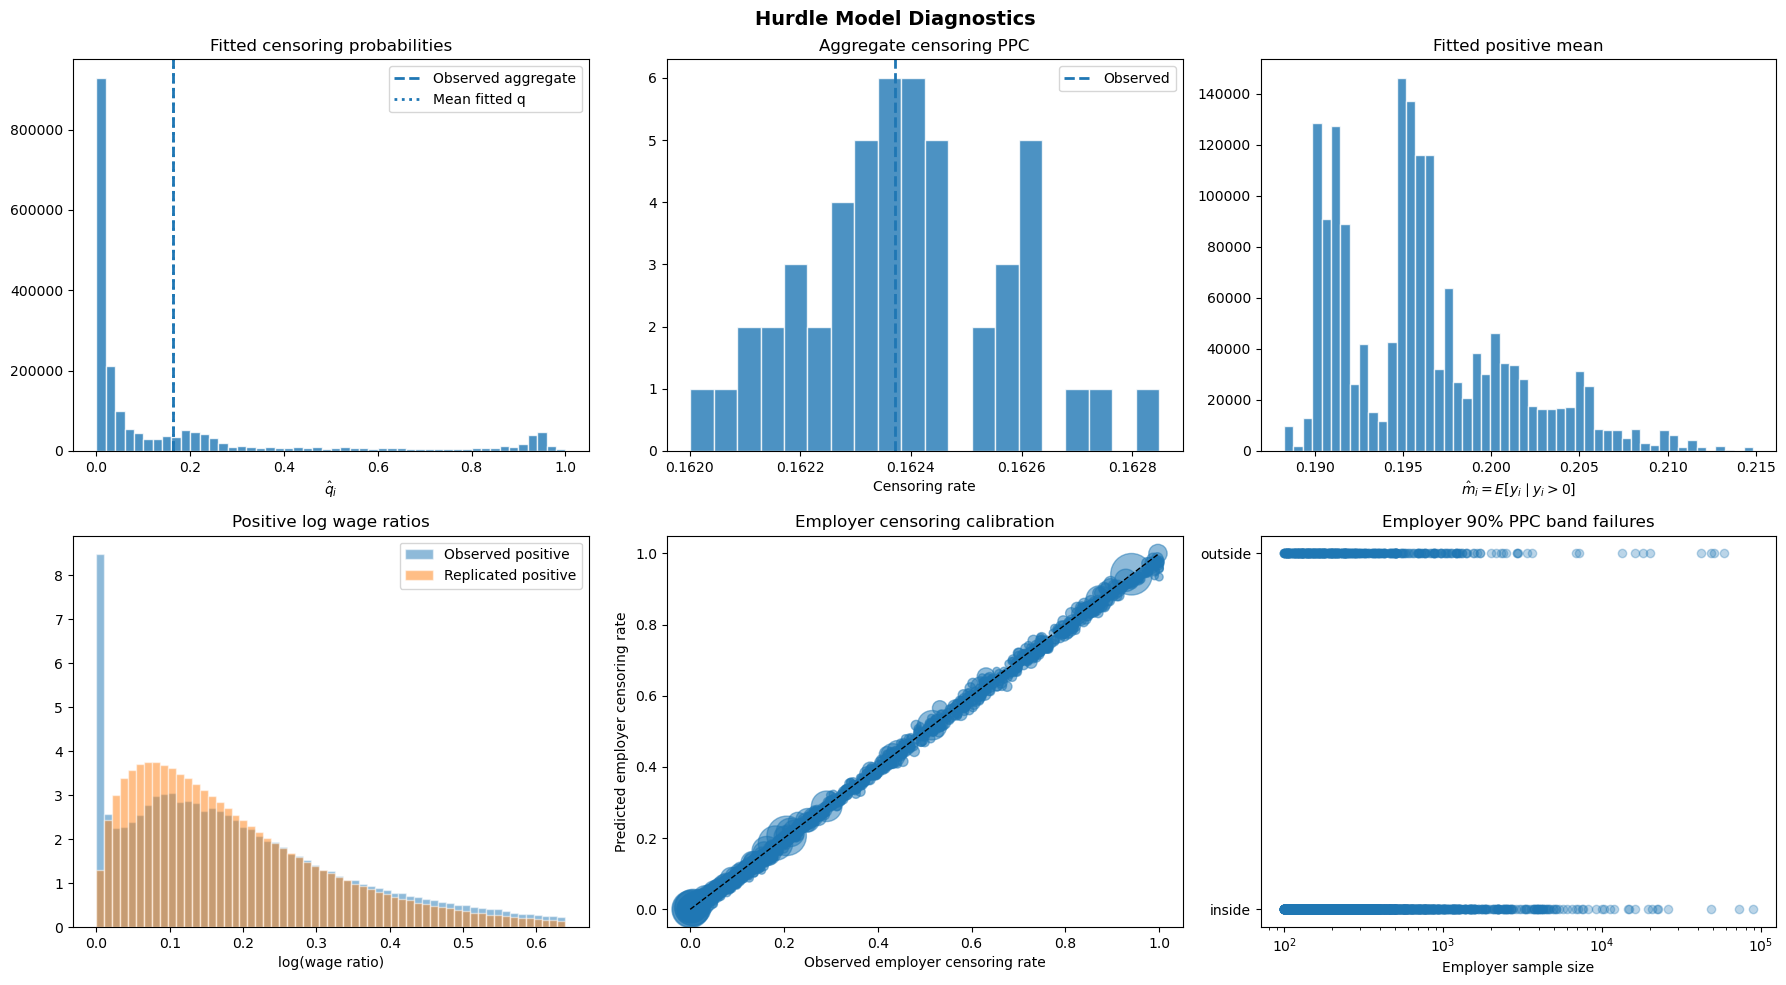

Baseline employers: 3587
Hurdle employers:   3587
Matched employers:  3587

Baseline vs hurdle comparison
------------------------------
Spearman baseline alpha vs hurdle positive-wage alpha: 0.5599
Spearman baseline alpha vs hurdle censoring alpha:     -0.6097
Bottom-30 baseline vs bottom-30 hurdle positive-wage overlap: 0.0%
Bottom-30 baseline vs top-30 hurdle suspicion overlap:        83.3%

Top hurdle suspicious employers:
                                          employer      n  obs_censor_rate  \
1560                                       infosys  41988         0.181838   
518                              capgemini america  22300         0.163049   
1331                          grandison management   3377         0.997335   
3008                        tech mahindra americas  10227         0.431896   
1374                        harmony public schools    496         0.981855   
687                            cognizant worldwide    617         0.987034   
1575               inno

In [3]:
# =============================================================================
# RUN EVERYTHING
# =============================================================================

data_h = prepare_data_hurdle(df)

result_hurdle = fit_hurdle_model(
    data_h,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000
)

ppc_h = ppc_hurdle_summary(result_hurdle, n_sim=50)
plot_hurdle_results(result_hurdle, ppc=ppc_h)

hurdle_effects = compare_hurdle_to_baseline_safe(
    result_hurdle=result_hurdle,
    result_baseline=result,
    df_baseline=df,
    top_n=30
)

In [51]:
# =============================================================================
# BOOTSTRAP PPC FOR HURDLE MODEL
# The above censoring parameters is plug-in, not accounting
# for parameter uncertainty.
# We use bootstrap to recalibrate the parameters.
# =============================================================================

from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def make_employer_indices(E, n_E):
    return [np.where(E == e)[0] for e in range(n_E)]


def _one_bootstrap_hurdle_fast(
    b,
    df,
    data_orig,
    emp_indices_orig,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    random_state=123,
    n_rep_per_boot=1
):
    rng = np.random.default_rng(random_state + b)

    try:
        boot_idx = rng.choice(np.arange(len(df)), size=len(df), replace=True)
        df_boot = df.iloc[boot_idx].copy()

        data_boot = prepare_data_hurdle(df_boot)

        if data_boot["censored"].mean() in [0, 1]:
            return None

        result_boot = fit_hurdle_model(
            data_boot,
            logistic_C=logistic_C,
            gamma_alpha=gamma_alpha,
            max_iter=max_iter,
            verbose=False
        )

        X_orig, _ = make_design_matrix(
            data_orig,
            encoder=result_boot["encoder"],
            fit_encoder=False
        )

        q_orig = result_boot["logit_model"].predict_proba(X_orig)[:, 1]
        m_orig = result_boot["gamma_model"].predict(X_orig)
        m_orig = np.maximum(m_orig, EPS)

        shape = result_boot["shape"]
        n_orig = data_orig["N"]
        n_E_orig = data_orig["N_E"]

        agg_rates = []
        mean_pos_values = []
        emp_rates_list = []

        for r in range(n_rep_per_boot):
            is_zero = rng.random(n_orig) < q_orig

            y_pos = rng.gamma(
                shape=shape,
                scale=m_orig / shape
            )

            y_rep = np.where(is_zero, 0.0, y_pos)

            zero_rep = (y_rep == 0)

            agg_rates.append(zero_rep.mean())
            mean_pos_values.append(y_rep[y_rep > 0].mean())

            emp_rates = np.zeros(n_E_orig)

            for e, idx_e in enumerate(emp_indices_orig):
                if len(idx_e) == 0:
                    emp_rates[e] = np.nan
                else:
                    emp_rates[e] = zero_rep[idx_e].mean()

            emp_rates_list.append(emp_rates)

        return {
            "agg_censor_rates": np.array(agg_rates),
            "mean_positive_values": np.array(mean_pos_values),
            "emp_censor_reps": np.array(emp_rates_list)
        }

    except Exception as err:
        print(f"Bootstrap {b} failed: {err}")
        return None


def bootstrap_ppc_hurdle_parallel_fast(
    df,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    random_state=123,
    n_jobs=4
):
    data_orig = prepare_data_hurdle(df)

    emp_indices_orig = make_employer_indices(
        data_orig["E"],
        data_orig["N_E"]
    )

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_one_bootstrap_hurdle_fast)(
            b=b,
            df=df,
            data_orig=data_orig,
            emp_indices_orig=emp_indices_orig,
            logistic_C=logistic_C,
            gamma_alpha=gamma_alpha,
            max_iter=max_iter,
            random_state=random_state,
            n_rep_per_boot=n_rep_per_boot
        )
        for b in range(B)
    )

    results = [r for r in results if r is not None]

    agg_censor_rates = np.concatenate(
        [r["agg_censor_rates"] for r in results]
    )

    mean_positive_values = np.concatenate(
        [r["mean_positive_values"] for r in results]
    )

    emp_censor_reps = np.vstack(
        [r["emp_censor_reps"] for r in results]
    )

    print("\nFast parallel bootstrap PPC finished.")
    print(f"Successful bootstrap fits: {len(results)}/{B}")

    return {
        "data_orig": data_orig,
        "agg_censor_rates": agg_censor_rates,
        "mean_positive_values": mean_positive_values,
        "emp_censor_reps": emp_censor_reps,
        "successful_boots": len(results),
    }


boot_ppc_fast = bootstrap_ppc_hurdle_parallel_fast(
    df=df,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    random_state=123,
    n_jobs=4
)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   36.2s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   58.1s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.8min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  4.9min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  6.0min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  7.2min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  8.5min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  9.4min finished



Fast parallel bootstrap PPC finished.
Successful bootstrap fits: 100/100


In [52]:
def summarize_bootstrap_ppc_hurdle(boot_ppc):
    data = boot_ppc["data_orig"]

    y = data["y"]
    censored = data["censored"]
    E = data["E"]
    employer_names = data["E_categories"]

    agg = boot_ppc["agg_censor_rates"]
    emp_reps = boot_ppc["emp_censor_reps"]

    print("\nBootstrap aggregate censoring PPC")
    print("----------------------------------")
    print(f"Observed censoring rate: {censored.mean():.4f}")
    print(f"Bootstrap predictive mean: {np.mean(agg):.4f}")
    print(
        "Bootstrap predictive 90% interval: "
        f"[{np.quantile(agg, 0.05):.4f}, {np.quantile(agg, 0.95):.4f}]"
    )

    n_E = data["N_E"]

    obs_emp_rate = np.zeros(n_E)
    pred_emp_mean = np.zeros(n_E)
    lo_emp = np.zeros(n_E)
    hi_emp = np.zeros(n_E)
    n_emp = np.zeros(n_E, dtype=int)
    outside = np.zeros(n_E, dtype=bool)

    for e in range(n_E):
        idx = np.where(E == e)[0]
        n_emp[e] = len(idx)

        obs_emp_rate[e] = censored[idx].mean()

        reps_e = emp_reps[:, e]
        reps_e = reps_e[np.isfinite(reps_e)]

        pred_emp_mean[e] = np.mean(reps_e)
        lo_emp[e] = np.quantile(reps_e, 0.05)
        hi_emp[e] = np.quantile(reps_e, 0.95)

        outside[e] = (
            obs_emp_rate[e] < lo_emp[e]
            or obs_emp_rate[e] > hi_emp[e]
        )

    outside_frac = outside.mean()

    print("\nBootstrap employer-level censoring PPC")
    print("---------------------------------------")
    print(f"Fraction outside 90% bands: {outside_frac:.4f}")

    emp_ppc = pd.DataFrame({
        "employer": employer_names,
        "n": n_emp,
        "obs_censor_rate": obs_emp_rate,
        "pred_censor_rate": pred_emp_mean,
        "lo_90": lo_emp,
        "hi_90": hi_emp,
        "outside_90": outside
    }).sort_values("n", ascending=False)

    return emp_ppc


emp_boot_ppc_fast = summarize_bootstrap_ppc_hurdle(boot_ppc_fast)


Bootstrap aggregate censoring PPC
----------------------------------
Observed censoring rate: 0.1624
Bootstrap predictive mean: 0.1624
Bootstrap predictive 90% interval: [0.1621, 0.1628]

Bootstrap employer-level censoring PPC
---------------------------------------
Fraction outside 90% bands: 0.1232


In [45]:
# =============================================================================
# PARALLEL EMPLOYER-CLUSTER BOOTSTRAP FOR HURDLE MODEL
# =============================================================================

from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, GammaRegressor
from scipy.special import expit, logit
from scipy.optimize import brentq


def calibrate_q_to_observed_rate(q, target_rate, eps=1e-8):
    """
    Shift the logit intercept of fitted probabilities q so that
    mean(q_calibrated) = target_rate.

    This changes only the intercept, not the relative rankings/effects.
    """
    q = np.clip(q, eps, 1 - eps)
    eta = logit(q)

    target_rate = np.clip(target_rate, eps, 1 - eps)

    def f(a):
        return expit(eta + a).mean() - target_rate

    # Usually this bracket is more than enough
    a_star = brentq(f, -50, 50)

    return expit(eta + a_star), a_star

def fit_hurdle_model_weighted_from_design(
    data,
    X_all,
    X_pos,
    pos_idx,
    sample_weight_all,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=300
):
    """
    Fit hurdle model using precomputed design matrices and sample weights.

    This avoids rebuilding the dataframe and re-encoding categorical variables
    inside every bootstrap replicate.
    """

    y = data["y"]
    censored = data["censored"].astype(int)
    y_pos = np.maximum(y[pos_idx], EPS)

    sample_weight_pos = sample_weight_all[pos_idx]

    # If bootstrap weights remove all zeros or positives, skip
    if np.sum(sample_weight_all * censored) == 0:
        return None
    if np.sum(sample_weight_all * (1 - censored)) == 0:
        return None

    logit_model = LogisticRegression(
        penalty="l2",
        C=logistic_C,
        fit_intercept=True,
        solver="lbfgs",
        max_iter=max_iter
    )

    logit_model.fit(
        X_all,
        censored,
        sample_weight=sample_weight_all
    )

    gamma_model = GammaRegressor(
        alpha=gamma_alpha,
        fit_intercept=True,
        max_iter=max_iter
    )

    gamma_model.fit(
        X_pos,
        y_pos,
        sample_weight=sample_weight_pos
    )

    q_hat = logit_model.predict_proba(X_all)[:, 1]
    m_hat = np.maximum(gamma_model.predict(X_all), EPS)
    m_hat_pos = np.maximum(gamma_model.predict(X_pos), EPS)

    pearson = ((y_pos - m_hat_pos) / np.maximum(m_hat_pos, EPS)) ** 2
    phi_hat = max(
        np.average(pearson, weights=sample_weight_pos),
        EPS
    )
    shape_hat = 1.0 / phi_hat

    return {
        "logit_model": logit_model,
        "gamma_model": gamma_model,
        "q_hat": q_hat,
        "m_hat": m_hat,
        "phi": phi_hat,
        "shape": shape_hat,
        "data": data
    }

In [46]:
def _one_weighted_cluster_bootstrap_hurdle_positive_weights(
    b,
    data,
    X_all,
    X_pos,
    pos_idx,
    emp_indices_orig,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=300,
    random_state=123,
    n_rep_per_boot=1
):
    rng = np.random.default_rng(random_state + b)

    try:
        E = data["E"]
        n_E = data["N_E"]
        n = data["N"]

        # ------------------------------------------------------------
        # Positive employer-cluster weights.
        # No employer is dropped entirely.
        # ------------------------------------------------------------
        employer_weights = rng.exponential(scale=1.0, size=n_E)

        sample_weight_all = employer_weights[E].astype(float)

        # Keep penalty strength comparable across bootstrap refits.
        sample_weight_all = sample_weight_all / np.mean(sample_weight_all)

        result_b = fit_hurdle_model_weighted_from_design(
            data=data,
            X_all=X_all,
            X_pos=X_pos,
            pos_idx=pos_idx,
            sample_weight_all=sample_weight_all,
            logistic_C=logistic_C,
            gamma_alpha=gamma_alpha,
            max_iter=max_iter
        )

        if result_b is None:
            return None

        q = result_b["q_hat"]
        m = result_b["m_hat"]
        shape = result_b["shape"]

        # Recenter bootstrap censoring probabilities to the original observed rate
        target_rate = data["censored"].mean()
        q, intercept_shift = calibrate_q_to_observed_rate(q, target_rate)

        # Employer effects are aligned to original categories
        n_L = data["K"]
        start_E = n_L
        end_E = n_L + n_E

        beta_logit = result_b["logit_model"].coef_.ravel()
        beta_gamma = result_b["gamma_model"].coef_.ravel()

        alpha_q_boot = beta_logit[start_E:end_E]
        alpha_y_boot = beta_gamma[start_E:end_E]

        agg_rates = []
        mean_pos_values = []
        emp_rates_list = []

        for r in range(n_rep_per_boot):
            is_zero = rng.random(n) < q

            y_pos_sim = rng.gamma(
                shape=shape,
                scale=m / shape
            )

            y_rep = np.where(is_zero, 0.0, y_pos_sim)
            zero_rep = y_rep == 0

            agg_rates.append(zero_rep.mean())

            if np.any(y_rep > 0):
                mean_pos_values.append(y_rep[y_rep > 0].mean())
            else:
                mean_pos_values.append(np.nan)

            emp_rates = np.zeros(n_E)

            for e, idx_e in enumerate(emp_indices_orig):
                emp_rates[e] = zero_rep[idx_e].mean()

            emp_rates_list.append(emp_rates)

        return {
            "boot_id": b,
            "agg_censor_rates": np.array(agg_rates),
            "mean_positive_values": np.array(mean_pos_values),
            "emp_censor_reps": np.array(emp_rates_list),
            "q_mean": float(q.mean()),
            "shape": float(shape),
            "alpha_q_boot": alpha_q_boot,
            "alpha_y_boot": alpha_y_boot,
            "intercept_shift": float(intercept_shift)
        }

    except Exception as err:
        print(f"Positive-weight cluster bootstrap {b} failed: {err}")
        return None

In [47]:
def bootstrap_ppc_hurdle_positive_weight_cluster_parallel(
    data,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=300,
    random_state=123,
    n_jobs=4,
    backend="threading"
):
    X_all, encoder = make_design_matrix(data, fit_encoder=True)

    pos_idx = np.where(data["positive"])[0]
    X_pos, _ = make_design_matrix(
        data,
        idx=pos_idx,
        encoder=encoder,
        fit_encoder=False
    )

    emp_indices_orig = make_employer_indices(
        data["E"],
        data["N_E"]
    )

    results = Parallel(
        n_jobs=n_jobs,
        verbose=10,
        backend=backend
    )(
        delayed(_one_weighted_cluster_bootstrap_hurdle_positive_weights)(
            b=b,
            data=data,
            X_all=X_all,
            X_pos=X_pos,
            pos_idx=pos_idx,
            emp_indices_orig=emp_indices_orig,
            logistic_C=logistic_C,
            gamma_alpha=gamma_alpha,
            max_iter=max_iter,
            random_state=random_state,
            n_rep_per_boot=n_rep_per_boot
        )
        for b in range(B)
    )

    results = [r for r in results if r is not None]

    if len(results) == 0:
        raise RuntimeError("All positive-weight cluster bootstrap replicates failed.")

    agg_censor_rates = np.concatenate(
        [r["agg_censor_rates"] for r in results]
    )

    mean_positive_values = np.concatenate(
        [r["mean_positive_values"] for r in results]
    )

    emp_censor_reps = np.vstack(
        [r["emp_censor_reps"] for r in results]
    )

    q_means = np.array([r["q_mean"] for r in results])
    shapes = np.array([r["shape"] for r in results])

    alpha_q_boot = np.vstack(
        [r["alpha_q_boot"] for r in results]
    )

    alpha_y_boot = np.vstack(
        [r["alpha_y_boot"] for r in results]
    )

    print("\nPositive-weight employer-cluster bootstrap finished.")
    print(f"Successful bootstrap fits: {len(results)}/{B}")
    print(
        f"q_mean 90% interval: "
        f"[{np.quantile(q_means, 0.05):.4f}, {np.quantile(q_means, 0.95):.4f}]"
    )

    return {
        "data_orig": data,
        "agg_censor_rates": agg_censor_rates,
        "mean_positive_values": mean_positive_values,
        "emp_censor_reps": emp_censor_reps,
        "q_means": q_means,
        "shapes": shapes,
        "alpha_q_boot": alpha_q_boot,
        "alpha_y_boot": alpha_y_boot,
        "successful_boots": len(results),
        "raw_results": results
    }

In [48]:
# ------------------------------------------------------------
# Run Cluster Bootstrap
# ------------------------------------------------------------

boot_cluster_pos_cal = bootstrap_ppc_hurdle_positive_weight_cluster_parallel(
    data=data_h,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=300,
    random_state=123,
    n_jobs=4,
    backend="threading"
)

emp_cluster_pos_cal = summarize_bootstrap_ppc_hurdle(boot_cluster_pos_cal)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   21.5s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   36.9s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   59.7s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  2.4min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  3.0min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  3.8min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  4.6min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  5.5min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  6.2min finished



Positive-weight employer-cluster bootstrap finished.
Successful bootstrap fits: 100/100
q_mean 90% interval: [0.1624, 0.1624]

Bootstrap aggregate censoring PPC
----------------------------------
Observed censoring rate: 0.1624
Bootstrap predictive mean: 0.1624
Bootstrap predictive 90% interval: [0.1621, 0.1626]

Bootstrap employer-level censoring PPC
---------------------------------------
Fraction outside 90% bands: 0.0599


In [49]:
def summarize_hurdle_effects_with_cluster_bootstrap(
    result_hurdle,
    boot_cluster_effects,
    top_n=30
):
    """
    Summarize hurdle employer effects with employer-cluster-bootstrap uncertainty.

    Inputs
    ------
    result_hurdle:
        Original fitted hurdle model.

    boot_cluster_effects:
        Output from bootstrap_ppc_hurdle_weighted_cluster_parallel()
        or bootstrap_ppc_hurdle_cluster_parallel_with_effects().
        Must contain:
            - alpha_q_boot
            - alpha_y_boot
            - data_orig

    top_n:
        Number of employers used for top-k stability probabilities.

    Returns
    -------
    effects:
        DataFrame with original effects, bootstrap intervals, bootstrap ranks,
        and probabilities of appearing in top-n lists.
    """

    # Original fitted effects
    effects = extract_hurdle_effects(result_hurdle).copy()

    # Align to original employer order
    original_employers = boot_cluster_effects["data_orig"]["E_categories"]

    effects = pd.DataFrame({"employer": original_employers}).merge(
        effects,
        on="employer",
        how="left"
    )

    alpha_q_boot = boot_cluster_effects["alpha_q_boot"]
    alpha_y_boot = boot_cluster_effects["alpha_y_boot"]

    # -------------------------------------------------------------------------
    # Bootstrap intervals for employer effects
    # -------------------------------------------------------------------------
    effects["alpha_q_boot_mean"] = np.nanmean(alpha_q_boot, axis=0)
    effects["alpha_q_boot_lo90"] = np.nanquantile(alpha_q_boot, 0.05, axis=0)
    effects["alpha_q_boot_hi90"] = np.nanquantile(alpha_q_boot, 0.95, axis=0)

    effects["alpha_y_boot_mean"] = np.nanmean(alpha_y_boot, axis=0)
    effects["alpha_y_boot_lo90"] = np.nanquantile(alpha_y_boot, 0.05, axis=0)
    effects["alpha_y_boot_hi90"] = np.nanquantile(alpha_y_boot, 0.95, axis=0)

    # -------------------------------------------------------------------------
    # Original standardized components
    # -------------------------------------------------------------------------
    z_q = (
        effects["alpha_q_censoring"]
        - effects["alpha_q_censoring"].mean()
    ) / (effects["alpha_q_censoring"].std() + EPS)

    z_y = (
        effects["alpha_y_positive_wage"]
        - effects["alpha_y_positive_wage"].mean()
    ) / (effects["alpha_y_positive_wage"].std() + EPS)

    effects["z_q_high_censoring"] = z_q
    effects["z_low_positive_wage"] = -z_y

    # Additive score: high if either high bunching or low positive wages
    effects["suspicion_additive"] = (
        effects["z_q_high_censoring"]
        + effects["z_low_positive_wage"]
    )

    # Stricter joint score: high only if both components are high
    effects["suspicion_joint"] = (
        np.maximum(effects["z_q_high_censoring"], 0)
        * np.maximum(effects["z_low_positive_wage"], 0)
    )

    # Conservative bottleneck score
    effects["suspicion_min"] = np.minimum(
        effects["z_q_high_censoring"],
        effects["z_low_positive_wage"]
    )

    # -------------------------------------------------------------------------
    # Bootstrap standardized suspicion scores
    # Standardize within each bootstrap replicate.
    # -------------------------------------------------------------------------
    q_mean_b = np.nanmean(alpha_q_boot, axis=1, keepdims=True)
    q_sd_b = np.nanstd(alpha_q_boot, axis=1, keepdims=True) + EPS

    y_mean_b = np.nanmean(alpha_y_boot, axis=1, keepdims=True)
    y_sd_b = np.nanstd(alpha_y_boot, axis=1, keepdims=True) + EPS

    z_q_boot = (alpha_q_boot - q_mean_b) / q_sd_b
    z_low_y_boot = -(alpha_y_boot - y_mean_b) / y_sd_b

    suspicion_add_boot = z_q_boot + z_low_y_boot

    suspicion_joint_boot = (
        np.maximum(z_q_boot, 0)
        * np.maximum(z_low_y_boot, 0)
    )

    suspicion_min_boot = np.minimum(z_q_boot, z_low_y_boot)

    effects["suspicion_add_boot_mean"] = np.nanmean(suspicion_add_boot, axis=0)
    effects["suspicion_add_boot_lo90"] = np.nanquantile(suspicion_add_boot, 0.05, axis=0)
    effects["suspicion_add_boot_hi90"] = np.nanquantile(suspicion_add_boot, 0.95, axis=0)

    effects["suspicion_joint_boot_mean"] = np.nanmean(suspicion_joint_boot, axis=0)
    effects["suspicion_joint_boot_lo90"] = np.nanquantile(suspicion_joint_boot, 0.05, axis=0)
    effects["suspicion_joint_boot_hi90"] = np.nanquantile(suspicion_joint_boot, 0.95, axis=0)

    effects["suspicion_min_boot_mean"] = np.nanmean(suspicion_min_boot, axis=0)
    effects["suspicion_min_boot_lo90"] = np.nanquantile(suspicion_min_boot, 0.05, axis=0)
    effects["suspicion_min_boot_hi90"] = np.nanquantile(suspicion_min_boot, 0.95, axis=0)

    # -------------------------------------------------------------------------
    # Bootstrap rank summaries
    # Lower rank = more extreme / more suspicious.
    # -------------------------------------------------------------------------
    B, n_E = alpha_q_boot.shape

    rank_q_boot = np.full((B, n_E), np.nan)
    rank_y_boot = np.full((B, n_E), np.nan)
    rank_add_boot = np.full((B, n_E), np.nan)
    rank_joint_boot = np.full((B, n_E), np.nan)
    rank_min_boot = np.full((B, n_E), np.nan)

    for b in range(B):
        # Threshold bunching: high alpha_q first
        valid_q = np.isfinite(alpha_q_boot[b])
        idx_q = np.where(valid_q)[0]
        order_q = np.argsort(-alpha_q_boot[b, valid_q])
        rank_q_boot[b, idx_q[order_q]] = np.arange(1, valid_q.sum() + 1)

        # Low positive wage: low alpha_y first
        valid_y = np.isfinite(alpha_y_boot[b])
        idx_y = np.where(valid_y)[0]
        order_y = np.argsort(alpha_y_boot[b, valid_y])
        rank_y_boot[b, idx_y[order_y]] = np.arange(1, valid_y.sum() + 1)

        # Additive suspicion: high score first
        valid_add = np.isfinite(suspicion_add_boot[b])
        idx_add = np.where(valid_add)[0]
        order_add = np.argsort(-suspicion_add_boot[b, valid_add])
        rank_add_boot[b, idx_add[order_add]] = np.arange(1, valid_add.sum() + 1)

        # Joint suspicion: high score first
        valid_joint = np.isfinite(suspicion_joint_boot[b])
        idx_joint = np.where(valid_joint)[0]
        order_joint = np.argsort(-suspicion_joint_boot[b, valid_joint])
        rank_joint_boot[b, idx_joint[order_joint]] = np.arange(1, valid_joint.sum() + 1)

        # Min suspicion: high score first
        valid_min = np.isfinite(suspicion_min_boot[b])
        idx_min = np.where(valid_min)[0]
        order_min = np.argsort(-suspicion_min_boot[b, valid_min])
        rank_min_boot[b, idx_min[order_min]] = np.arange(1, valid_min.sum() + 1)

    # -------------------------------------------------------------------------
    # Rank intervals
    # -------------------------------------------------------------------------
    effects["rank_q_boot_mean"] = np.nanmean(rank_q_boot, axis=0)
    effects["rank_q_boot_lo90"] = np.nanquantile(rank_q_boot, 0.05, axis=0)
    effects["rank_q_boot_hi90"] = np.nanquantile(rank_q_boot, 0.95, axis=0)

    effects["rank_y_boot_mean"] = np.nanmean(rank_y_boot, axis=0)
    effects["rank_y_boot_lo90"] = np.nanquantile(rank_y_boot, 0.05, axis=0)
    effects["rank_y_boot_hi90"] = np.nanquantile(rank_y_boot, 0.95, axis=0)

    effects["rank_add_boot_mean"] = np.nanmean(rank_add_boot, axis=0)
    effects["rank_add_boot_lo90"] = np.nanquantile(rank_add_boot, 0.05, axis=0)
    effects["rank_add_boot_hi90"] = np.nanquantile(rank_add_boot, 0.95, axis=0)

    effects["rank_joint_boot_mean"] = np.nanmean(rank_joint_boot, axis=0)
    effects["rank_joint_boot_lo90"] = np.nanquantile(rank_joint_boot, 0.05, axis=0)
    effects["rank_joint_boot_hi90"] = np.nanquantile(rank_joint_boot, 0.95, axis=0)

    effects["rank_min_boot_mean"] = np.nanmean(rank_min_boot, axis=0)
    effects["rank_min_boot_lo90"] = np.nanquantile(rank_min_boot, 0.05, axis=0)
    effects["rank_min_boot_hi90"] = np.nanquantile(rank_min_boot, 0.95, axis=0)

    # -------------------------------------------------------------------------
    # Probability of appearing in top-n lists
    # -------------------------------------------------------------------------
    effects[f"prob_top{top_n}_bunching"] = np.nanmean(
        rank_q_boot <= top_n,
        axis=0
    )

    effects[f"prob_top{top_n}_low_positive_wage"] = np.nanmean(
        rank_y_boot <= top_n,
        axis=0
    )

    effects[f"prob_top{top_n}_additive"] = np.nanmean(
        rank_add_boot <= top_n,
        axis=0
    )

    effects[f"prob_top{top_n}_joint"] = np.nanmean(
        rank_joint_boot <= top_n,
        axis=0
    )

    effects[f"prob_top{top_n}_min"] = np.nanmean(
        rank_min_boot <= top_n,
        axis=0
    )

    return effects

In [50]:
effects_boot = summarize_hurdle_effects_with_cluster_bootstrap(
    result_hurdle=result_hurdle,
    boot_cluster_effects=boot_cluster_fast,
    top_n=30
)

top_bunching_boot = effects_boot.sort_values(
    "alpha_q_censoring",
    ascending=False
).head(30)

print("Top threshold-bunching employers:")
print(top_bunching_boot[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_q_censoring",
    "alpha_q_boot_lo90",
    "alpha_q_boot_hi90",
    "prob_top30_bunching"
]])

top_low_positive_wage_boot = effects_boot.sort_values(
    "alpha_y_positive_wage",
    ascending=True
).head(30)

print("\nTop low-positive-wage employers:")
print(top_low_positive_wage_boot[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_y_positive_wage",
    "alpha_y_boot_lo90",
    "alpha_y_boot_hi90",
    "prob_top30_low_positive_wage"
]])

top_additive_boot = effects_boot.sort_values(
    "suspicion_additive",
    ascending=False
).head(30)

print("\nTop additive suspicious employers:")
print(top_additive_boot[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_q_censoring",
    "alpha_y_positive_wage",
    "z_q_high_censoring",
    "z_low_positive_wage",
    "suspicion_additive",
    "suspicion_add_boot_lo90",
    "suspicion_add_boot_hi90",
    "prob_top30_additive"
]])

Top threshold-bunching employers:
                                          employer      n  obs_censor_rate  \
1331                          grandison management   3377         0.997335   
1374                        harmony public schools    496         0.981855   
687                            cognizant worldwide    617         0.987034   
1575               innovative consulting solutions    507         0.996055   
1232                               fujitsu america    357         0.994398   
1234                         fujitsu north america    284         1.000000   
1539                               infobiz systems    238         1.000000   
2226   novartis institutes for biomedical research    521         0.975048   
2520                                       rapidit    238         1.000000   
3167                          trizetto a cognizant    176         1.000000   
78                                    advantage it    290         0.989655   
2454                          